In [1]:
!pip install python-docx joblib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 20.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


In [3]:
import os
import json
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from docx import Document
from datetime import datetime
import joblib

# CONFIGURATION

In [4]:
BASE_SAVE_DIR = "/users/"

DATASET_NAME = "CIC_IoT_2023"
DATASET_DIR = os.path.join(BASE_SAVE_DIR, DATASET_NAME)

CLIENTS_DIR = os.path.join(DATASET_DIR, "clients_non_iid")
os.makedirs(CLIENTS_DIR, exist_ok=True)

N_CLIENTS = 25
DIRICHLET_ALPHA = 0.3

print("DATASET_DIR:", DATASET_DIR)
print("CLIENTS_DIR:", CLIENTS_DIR)
print("N_CLIENTS:", N_CLIENTS)
print("DIRICHLET_ALPHA:", DIRICHLET_ALPHA)

DATASET_DIR: /users/
CLIENTS_DIR: /users/
N_CLIENTS: 25
DIRICHLET_ALPHA: 0.3


# LOAD TRAIN LATENT FEATURES & LABELS

In [5]:
train_latent_path = os.path.join(DATASET_DIR, "train_latent.npy")
y_train_path      = os.path.join(DATASET_DIR, "y_train.npy")
label_encoder_path = os.path.join(DATASET_DIR, "label_encoder.pkl")

assert os.path.exists(train_latent_path), f"Missing: {train_latent_path}"
assert os.path.exists(y_train_path), f"Missing: {y_train_path}"
assert os.path.exists(label_encoder_path), f"Missing: {label_encoder_path}"

X_train = np.load(train_latent_path)
y_train = np.load(y_train_path)
label_encoder = joblib.load(label_encoder_path)

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Total classes:", num_classes)
print("Sample class names:", class_names[:20])
if num_classes > 20:
    print(f"... and {num_classes - 20} more")

X_train shape: (31513463, 64)
y_train shape: (31513463,)
Total classes: 34
Sample class names: ['BACKDOOR_MALWARE', 'BENIGN', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SLOWLORIS', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'DOS-SYN_FLOOD']
... and 14 more


# GLOBAL CLASS DISTRIBUTION (TRAIN SPLIT)

Global Class Distribution (encoded labels):
0 - BACKDOOR_MALWARE : 2155
1 - BENIGN : 735961
2 - BROWSERHIJACKING : 3941
3 - COMMANDINJECTION : 3618
4 - DDOS-ACK_FRAGMENTATION : 190955
5 - DDOS-HTTP_FLOOD : 19318
6 - DDOS-ICMP_FLOOD : 4825281
7 - DDOS-ICMP_FRAGMENTATION : 303210
8 - DDOS-PSHACK_FLOOD : 2744260
9 - DDOS-RSTFINFLOOD : 2710966
10 - DDOS-SLOWLORIS : 15680
11 - DDOS-SYNONYMOUSIP_FLOOD : 2411961
12 - DDOS-SYN_FLOOD : 2720291
13 - DDOS-TCP_FLOOD : 3014260
14 - DDOS-UDP_FLOOD : 3626719
15 - DDOS-UDP_FRAGMENTATION : 192436
16 - DICTIONARYBRUTEFORCE : 8765
17 - DNS_SPOOFING : 120028
18 - DOS-HTTP_FLOOD : 48159
19 - DOS-SYN_FLOOD : 1359523
20 - DOS-TCP_FLOOD : 1790779
21 - DOS-UDP_FLOOD : 2224126
22 - MIRAI-GREETH_FLOOD : 664567
23 - MIRAI-GREIP_FLOOD : 503759
24 - MIRAI-UDPPLAIN : 596886
25 - MITM-ARPSPOOFING : 206128
26 - RECON-HOSTDISCOVERY : 90074
27 - RECON-OSSCAN : 65779
28 - RECON-PINGSWEEP : 1513
29 - RECON-PORTSCAN : 55111
30 - SQLINJECTION : 3515
31 - UPLOADING_ATTACK : 

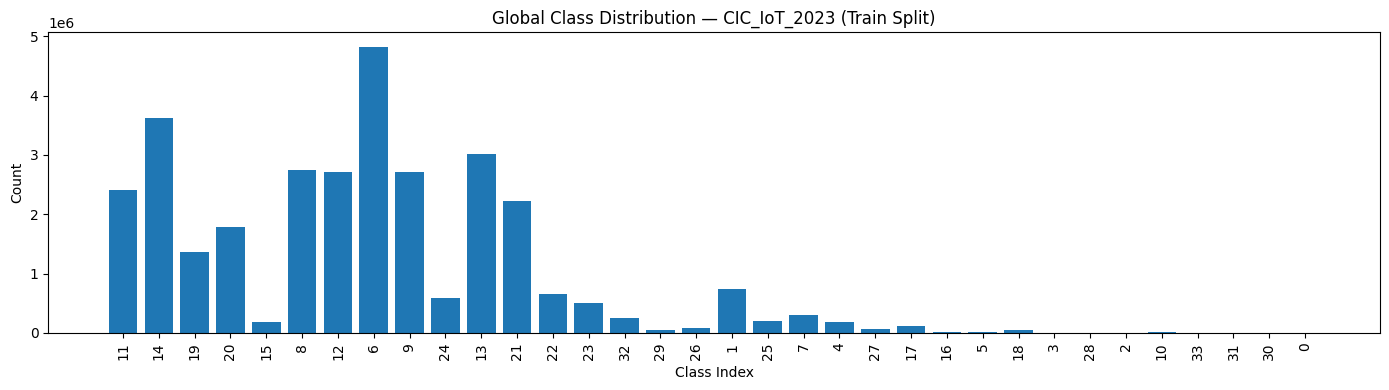

In [6]:
global_counts = Counter(y_train.tolist())

print("Global Class Distribution (encoded labels):")
for cls_idx, cnt in sorted(global_counts.items()):
    print(f"{cls_idx} - {class_names[cls_idx]} : {cnt}")

plt.figure(figsize=(14, 4))
plt.bar(
    [str(k) for k in global_counts.keys()],
    list(global_counts.values())
)
plt.title("Global Class Distribution — CIC_IoT_2023 (Train Split)")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Dirichlet Non-IID Partitioning

In [7]:
def dirichlet_partition(y, n_clients, alpha, seed=42):

    np.random.seed(seed)
    random.seed(seed)

    all_indices = np.arange(len(y))
    unique_classes = sorted(list(set(y)))

    # Map each class → its indices
    class_to_indices = {
        c: all_indices[y == c] for c in unique_classes
    }
    for c in class_to_indices:
        np.random.shuffle(class_to_indices[c])

    client_samples = [[] for _ in range(n_clients)]

    # For each class, split its samples across clients according to Dirichlet
    for cls, idxs in class_to_indices.items():
        n = len(idxs)
        if n == 0:
            continue

        # Dirichlet proportions for this class
        proportions = np.random.dirichlet([alpha] * n_clients)

        # Convert proportions to integer sample counts
        counts = (proportions * n).astype(int)
        diff = n - counts.sum()
        # Fix rounding leftovers
        for _ in range(diff):
            j = np.random.randint(0, n_clients)
            counts[j] += 1

        start = 0
        for client_id in range(n_clients):
            c_count = counts[client_id]
            if c_count > 0:
                client_samples[client_id].extend(
                    idxs[start:start + c_count]
                )
                start += c_count

    # Shuffle indices inside each client
    for cid in range(n_clients):
        arr = np.array(client_samples[cid])
        np.random.shuffle(arr)
        client_samples[cid] = arr

    return client_samples

# PARTITION INTO NON-IID CLIENTS

In [8]:
client_indices = dirichlet_partition(
    y=y_train,
    n_clients=N_CLIENTS,
    alpha=DIRICHLET_ALPHA,
    seed=42
)

total_assigned = sum(len(idx) for idx in client_indices)
print("Total assigned samples:", total_assigned)
print("Original train samples:", len(y_train))
assert total_assigned == len(y_train), "Mismatch in sample counts!"

Total assigned samples: 31513463
Original train samples: 31513463


# INSPECT CLIENT DISTRIBUTIONS

In [9]:
def class_distribution(indices):
    sub_labels = y_train[indices]
    c = Counter(sub_labels.tolist())
    return {int(k): int(v) for k, v in sorted(c.items())}

client_stats = []

for cid, idxs in enumerate(client_indices):
    dist = class_distribution(idxs)
    num_samples = len(idxs)
    num_classes_in_client = len(dist)

    # Top-3 most frequent classes in this client
    top3 = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:3]
    top3_readable = [
        f"{cls_idx}({class_names[cls_idx]}):{cnt}" for cls_idx, cnt in top3
    ]

    client_stats.append({
        "client_id": cid,
        "num_samples": num_samples,
        "num_classes": num_classes_in_client,
        "class_distribution": dist,
        "top_classes": top3_readable
    })

for s in client_stats:
    print(f"\nClient {s['client_id']}:")
    print("  Samples     :", s["num_samples"])
    print("  #Classes    :", s["num_classes"])
    print("  Top Classes :", ", ".join(s["top_classes"]))


Client 0:
  Samples     : 1008238
  #Classes    : 34
  Top Classes : 6(DDOS-ICMP_FLOOD):340903, 8(DDOS-PSHACK_FLOOD):236771, 12(DDOS-SYN_FLOOD):172940

Client 1:
  Samples     : 425325
  #Classes    : 33
  Top Classes : 20(DOS-TCP_FLOOD):184103, 21(DOS-UDP_FLOOD):70786, 9(DDOS-RSTFINFLOOD):40095

Client 2:
  Samples     : 1579292
  #Classes    : 30
  Top Classes : 8(DDOS-PSHACK_FLOOD):432157, 9(DDOS-RSTFINFLOOD):337973, 12(DDOS-SYN_FLOOD):164644

Client 3:
  Samples     : 1693386
  #Classes    : 34
  Top Classes : 6(DDOS-ICMP_FLOOD):647989, 21(DOS-UDP_FLOOD):392029, 11(DDOS-SYNONYMOUSIP_FLOOD):133396

Client 4:
  Samples     : 705102
  #Classes    : 32
  Top Classes : 21(DOS-UDP_FLOOD):237649, 8(DDOS-PSHACK_FLOOD):136766, 9(DDOS-RSTFINFLOOD):78019

Client 5:
  Samples     : 844729
  #Classes    : 33
  Top Classes : 14(DDOS-UDP_FLOOD):378748, 8(DDOS-PSHACK_FLOOD):123596, 13(DDOS-TCP_FLOOD):109525

Client 6:
  Samples     : 1874801
  #Classes    : 31
  Top Classes : 11(DDOS-SYNONYMOUSIP

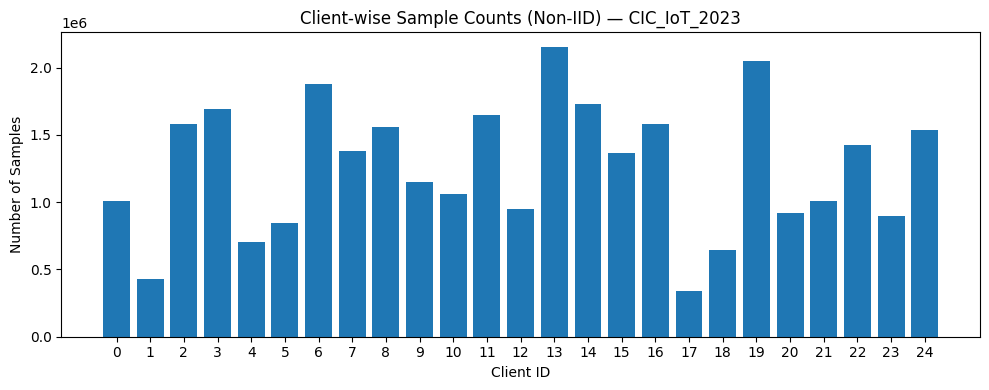

In [10]:
sizes = [s["num_samples"] for s in client_stats]

plt.figure(figsize=(10, 4))
plt.bar(range(N_CLIENTS), sizes)
plt.title("Client-wise Sample Counts (Non-IID) — CIC_IoT_2023")
plt.xlabel("Client ID")
plt.ylabel("Number of Samples")
plt.xticks(range(N_CLIENTS))
plt.tight_layout()
plt.show()

# Save Client Datasets

In [11]:
for cid, idxs in enumerate(client_indices):
    client_folder = os.path.join(CLIENTS_DIR, f"client_{cid}")
    os.makedirs(client_folder, exist_ok=True)

    Xc = X_train[idxs]
    yc = y_train[idxs]

    np.save(os.path.join(client_folder, "X.npy"), Xc)
    np.save(os.path.join(client_folder, "y.npy"), yc)

print("✔ Saved all client datasets under:", CLIENTS_DIR)

✔ Saved all client datasets under: /users/


# Save Metadata JSON

In [12]:
metadata = {
    "dataset_name": DATASET_NAME,
    "generated_at": datetime.now().isoformat(),
    "n_clients": N_CLIENTS,
    "dirichlet_alpha": DIRICHLET_ALPHA,
    "global": {
        "num_samples": int(len(y_train)),
        "num_classes": int(num_classes),
        "class_index_to_name": {int(i): str(name) for i, name in enumerate(class_names)},
        "class_distribution": {int(k): int(v) for k, v in sorted(global_counts.items())},
    },
    "clients": [],
}

for s in client_stats:
    cid = s["client_id"]
    metadata["clients"].append({
        "client_id": cid,
        "num_samples": int(s["num_samples"]),
        "num_classes": int(s["num_classes"]),
        "class_distribution": {int(k): int(v) for k, v in s["class_distribution"].items()},
        "top_classes": s["top_classes"],
    })

meta_path = os.path.join(CLIENTS_DIR, "clients_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("✔ Metadata JSON saved to:", meta_path)

✔ Metadata JSON saved to: /users/


# DOCX Summary Report

In [13]:
doc = Document()
doc.add_heading(f"Client Partition Summary — {DATASET_NAME}", level=1)

doc.add_paragraph(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
doc.add_paragraph(f"Number of clients: {N_CLIENTS}")
doc.add_paragraph(f"Dirichlet alpha (Non-IID strength): {DIRICHLET_ALPHA}")
doc.add_paragraph(f"Total train samples: {len(y_train)}")
doc.add_paragraph(f"Number of classes: {num_classes}")

doc.add_heading("Global Class Distribution", level=2)
for cls_idx, cnt in sorted(global_counts.items()):
    doc.add_paragraph(
        f"{cls_idx} ({class_names[cls_idx]}): {cnt}",
        style="List Bullet"
    )

doc.add_heading("Client-wise Summary", level=2)
table = doc.add_table(rows=1, cols=5)
hdr = table.rows[0].cells
hdr[0].text = "Client ID"
hdr[1].text = "#Samples"
hdr[2].text = "#Classes"
hdr[3].text = "Top 3 Classes"
hdr[4].text = "Class Dist (truncated)"

for s in client_stats:
    row = table.add_row().cells
    row[0].text = str(s["client_id"])
    row[1].text = str(s["num_samples"])
    row[2].text = str(s["num_classes"])
    row[3].text = ", ".join(s["top_classes"])

    dist_items = list(s["class_distribution"].items())
    dist_str = ", ".join(
        f"{cls}({class_names[cls]}):{cnt}" for cls, cnt in dist_items[:5]
    )
    if len(dist_items) > 5:
        dist_str += " ..."
    row[4].text = dist_str

docx_path = os.path.join(CLIENTS_DIR, "clients_metadata_summary.docx")
doc.save(docx_path)

print("✔ DOCX summary saved to:", docx_path)

✔ DOCX summary saved to: /users/
